In [1]:
from typing import TypedDict, Literal, Optional

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt

In [2]:
class ApprovalState(TypedDict):
    action_details: str
    status: Optional[Literal['pending', 'approved', 'rejected']]

In [3]:
def approval_node(state: ApprovalState) -> Command[Literal['proceed', 'cancel']]:

    decision = interrupt(
        {
            "question": "approve tis action?",
            "details": state["action_details"]
        }
    )

    return Command(goto="proceed" if decision else "cancel")

In [4]:
def proceed_node(state: ApprovalState):
    return {"status": "approved"}

In [5]:
def cancel_node(state: ApprovalState):
    return{"status": "rejected"}

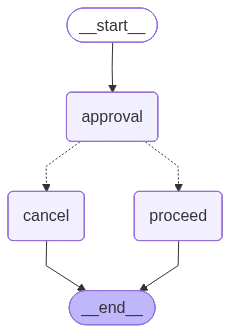

In [6]:
graph = StateGraph(ApprovalState)

graph.add_node('approval', approval_node)
graph.add_node('proceed', proceed_node)
graph.add_node('cancel', cancel_node)

graph.add_edge(START, 'approval')
graph.add_edge('proceed', END)
graph.add_edge('cancel', END)

checkpoint = MemorySaver()

hil_graph = graph.compile(checkpointer=checkpoint)

hil_graph

In [9]:
config = {'configurable': {'thread_id': 'vj123'}}

initial = hil_graph.invoke(
    {'action_details': 'send daily summary',
     'status': 'pending'},
     config=config
)

print(initial["__interrupt__"])

[Interrupt(value={'question': 'approve tis action?', 'details': 'send daily summary'}, id='d13a4e4304e9d07c468ab64cf093fdf2')]


In [10]:
resumed = hil_graph.invoke(Command(resume=True), config=config)
resumed

{'action_details': 'send daily summary', 'status': 'approved'}

In [14]:
config = {'configurable': {'thread_id': '123'}}

initial = hil_graph.invoke(
    {'action_details': 'send daily summary',
     'status': 'pending'},
     config=config
)

initial["__interrupt__"]

[Interrupt(value={'question': 'approve tis action?', 'details': 'send daily summary'}, id='83e6ad97513a1528f58050967682ca18')]

In [15]:
resumed = hil_graph.invoke(Command(resume=False), config=config)
print(resumed['status'])

rejected
